In [2]:
path = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\bla.tif"


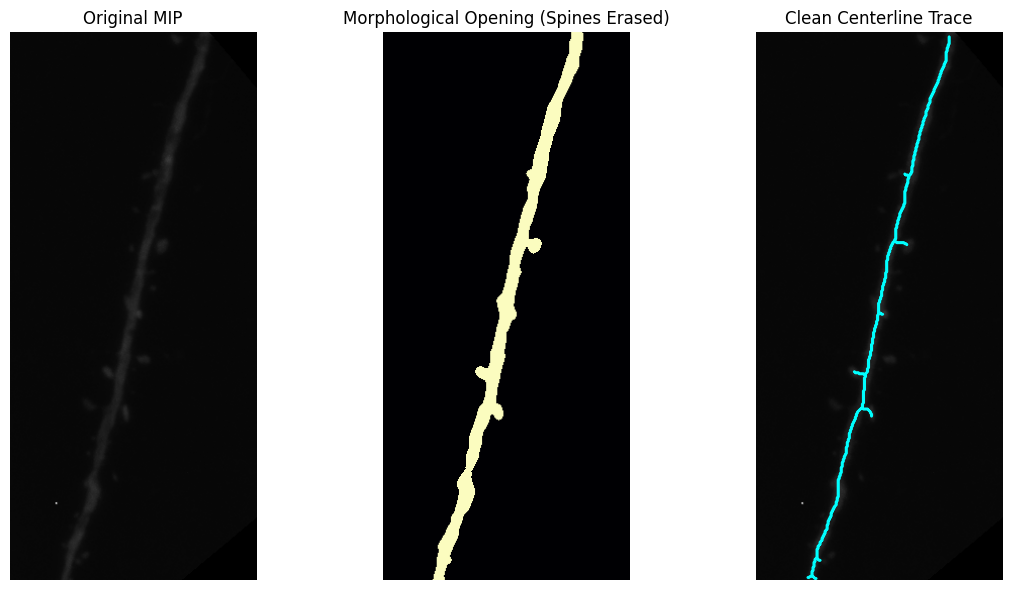

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure
import tifffile

def extract_clean_shaft_centerline(tiff_path, spine_radius_px=4):
    """
    Extracts a clean, single-line skeleton of the dendrite shaft,
    using morphological opening to physically erase spine protrusions.
    """
    # 1. Load the Z-stack and generate the MIP
    volume = tifffile.imread(tiff_path)
    if volume.ndim == 3:
        mip = np.max(volume, axis=0).astype(float)
    else:
        mip = volume.astype(float)
        
    # 2. Gaussian Blur to smooth intensity variations
    smoothed = filters.gaussian(mip, sigma=2.0)
    
    # 3. Thresholding (Otsu)
    thresh_val = filters.threshold_otsu(smoothed)
    binary_mask = smoothed > thresh_val
    
    # 4. THE SPINE KILLER: Morphological Opening
    # This erases any structure smaller than the footprint.
    # Adjust 'spine_radius_px' so it is larger than your biggest spine width
    # but smaller than the thickness of the main dendritic shaft.
    footprint = morphology.disk(spine_radius_px)
    shaft_only = morphology.opening(binary_mask, footprint)
    
    # 5. Isolate the largest connected component 
    # (Removes any floating disconnected spine heads that survived)
    labeled_image = measure.label(shaft_only, connectivity=2)
    if labeled_image.max() == 0:
        return mip, np.zeros_like(mip, dtype=bool) # Returns empty if nothing detected
        
    # Find the label with the largest area
    regions = measure.regionprops(labeled_image)
    largest_region = max(regions, key=lambda x: x.area)
    clean_shaft_mask = (labeled_image == largest_region.label)
    
    # 6. Skeletonize the cleaned shaft
    centerline = morphology.skeletonize(clean_shaft_mask)
    
    return mip, clean_shaft_mask, centerline

# --- Execution and Plotting ---
# Replace with your actual TIFF filename
mip, clean_shaft, centerline = extract_clean_shaft_centerline(path, spine_radius_px=4)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mip, cmap='gray')
axes[0].set_title('Original MIP')
axes[0].axis('off')

axes[1].imshow(clean_shaft, cmap='magma')
axes[1].set_title('Morphological Opening (Spines Erased)')
axes[1].axis('off')

axes[2].imshow(mip, cmap='gray')
axes[2].contour(centerline, colors='cyan', linewidths=1.5)
axes[2].set_title('Clean Centerline Trace')
axes[2].axis('off')

plt.tight_layout()
plt.show()

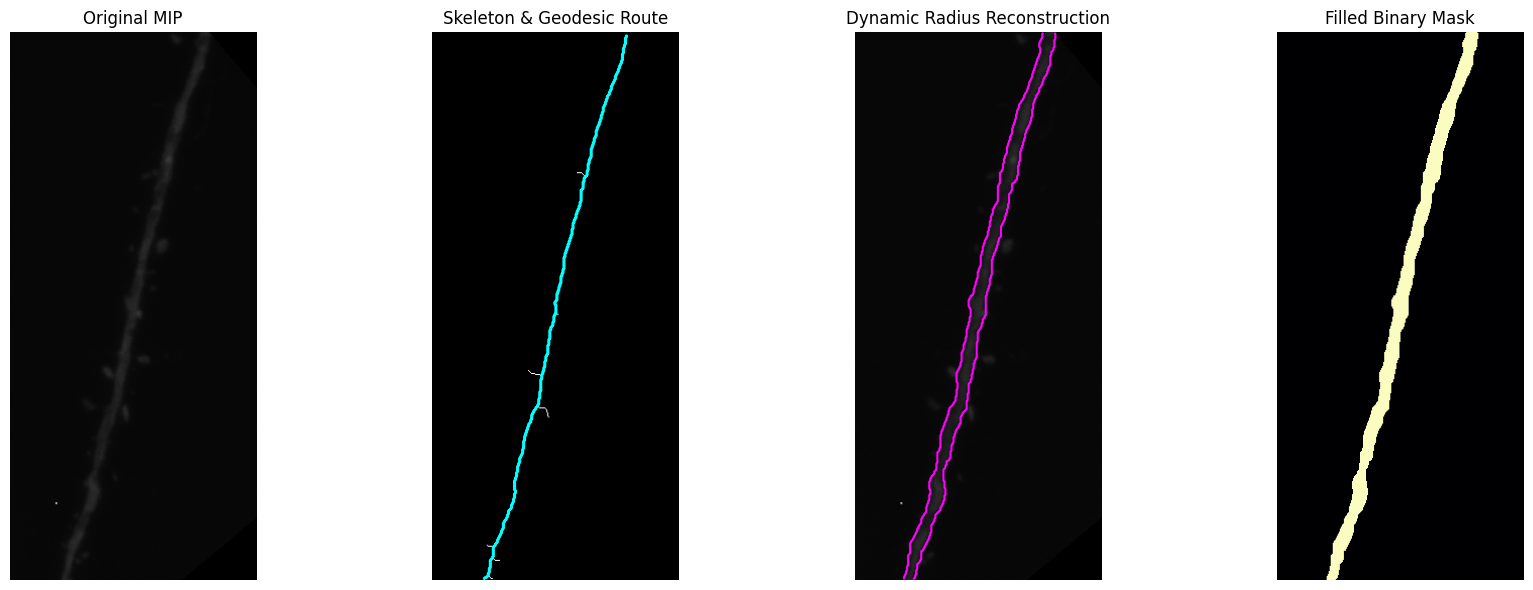

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.spatial.distance import pdist, squareform
from skimage import morphology, filters, measure, graph
import tifffile

def reconstruct_shaft_geodesic(tiff_path):
    """
    Extracts the main dendrite shaft by routing a geodesic path down the 
    skeleton and dynamically reconstructing the volume using local radii.
    """
    # 1. Load and create a clean binary mask
    volume = tifffile.imread(tiff_path)
    mip = np.max(volume, axis=0) if volume.ndim == 3 else volume
    
    smoothed = filters.gaussian(mip.astype(float), sigma=1.0)
    binary_mask = smoothed > filters.threshold_otsu(smoothed)
    
    # Keep only the largest connected component to ignore floating noise
    labeled = measure.label(binary_mask)
    if labeled.max() == 0:
        return mip, binary_mask, binary_mask
    largest_cc = (labeled == np.argmax(np.bincount(labeled.flat)[1:]) + 1)
    
    # 2. Compute Distance Transform and Skeleton
    edt = ndi.distance_transform_edt(largest_cc)
    skel = morphology.skeletonize(largest_cc)
    
    # 3. Find Endpoints of the Skeleton
    # A skeleton endpoint has exactly 1 neighbor in a 3x3 grid
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    neighbor_count = ndi.convolve(skel.astype(int), kernel, mode='constant')
    endpoints = np.argwhere((neighbor_count == 11) & skel)
    
    # Find the two endpoints furthest from each other (the start and end of the shaft)
    if len(endpoints) < 2:
        return mip, skel, largest_cc
        
    D = squareform(pdist(endpoints))
    i, j = np.unravel_index(np.argmax(D), D.shape)
    start_pt = tuple(endpoints[i])
    end_pt = tuple(endpoints[j])
    
    # 4. Geodesic Shortest Path (The Backbone)
    # Punish background pixels heavily so the route stays strictly on the skeleton
    cost_map = np.where(skel, 1, 1e6)
    path, _ = graph.route_through_array(cost_map, start=start_pt, end=end_pt, fully_connected=True)
    
    # 5. Medial Axis Reconstruction
    reconstructed_shaft = np.zeros_like(largest_cc)
    Y, X = np.indices(largest_cc.shape)
    
    # Redraw the shaft dynamically based on the exact radius at every backbone step
    for r, c in path:
        radius = edt[r, c]
        if radius > 0:
            # +0.5 prevents jagged sub-pixel digitization artifacts on the edges
            circle = (Y - r)**2 + (X - c)**2 <= (radius + 0.5)**2
            reconstructed_shaft |= circle
            
    return mip, skel, path, reconstructed_shaft

# --- Execution and Plotting ---
mip, skeleton, path, final_shaft = reconstruct_shaft_geodesic(path)

# Create a visual for the backbone path
path_img = np.zeros_like(mip, dtype=bool)
for r, c in path:
    path_img[r, c] = True

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(mip, cmap='gray')
axes[0].set_title('Original MIP')
axes[0].axis('off')

# Display the skeleton vs the calculated shortest path
axes[1].imshow(skeleton, cmap='gray')
axes[1].contour(path_img, colors='cyan', linewidths=1.5)
axes[1].set_title('Skeleton & Geodesic Route')
axes[1].axis('off')

# Display the exact physiological reconstruction (Outline)
axes[2].imshow(mip, cmap='gray')
axes[2].contour(final_shaft, colors='magenta', linewidths=1.5)
axes[2].set_title('Dynamic Radius Reconstruction')
axes[2].axis('off')

# Display the Filled Binary Mask directly
axes[3].imshow(final_shaft, cmap='magma')
axes[3].set_title('Filled Binary Mask')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# --- Saving the Mask ---
# The boolean mask can be saved directly as a standard 8-bit TIFF
# final_shaft_uint8 = (final_shaft * 255).astype(np.uint8)
# tifffile.imwrite("filled_shaft_mask.tif", final_shaft_uint8)